# 1. Business understanding

Data includes coordinates for clients locations.

Colums in dataset:
 - `clientid` - The unique identifier for the customer
 - `x` - The x coordinate of the customer's location, when plotted into a 2D plane
 - `y` - The y coordinate of the customer's location, when plotted into a 2D plane

The goal is to provide a model that can cluster suitable drone hub locations based on customer locations. Unsupervised clustering methods are suitable for this problem because the data does not contain predefined cluster labels. We also compare the results for agglomerative hierachical clustering.

# 2. Data understanding

In [1]:
import pandas as pd
import seaborn as sns
import time
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("drone_cust_locations.csv", sep=";")

display(df.head())

,clientid,x,y
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298


In [3]:
df.dtypes

clientid      int64
x           float64
y           float64
dtype: object

## Vizualized customer locations

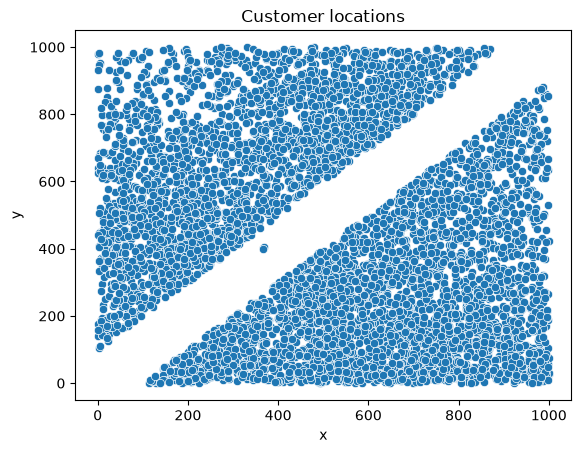

In [4]:
sns.scatterplot(
    data=df,
    x="x",
    y="y"
)

plt.title("Customer locations")
plt.show()

## Data breakdown

Data includes only `clientid`, `x` and `y` coordinates.

The clients are distributed across most of the coordinate area, but the distribution is not uniform. Several denser customer regions can be observed, and there is also a visible lower-density area across the middle of the plot. This suggests that multiple depot locations could reduce the distances between customers and their nearest depot.

# 3. Data preparation

Scaling is not necessary because both `x` and `y` are coordinates measured on the same scale and have approximately the same range.

Datas coordinates `x` and `y` is already a type `float64` so no need for conversion.

We only need to separate coordinates `x` and `y` from data to a new dataframe called `X`, so it can be fed to the algorithm.

Lets separate the coordinates `x` and `y` to a new dataframe.

In [5]:
X = df[["x", "y"]]

In [6]:
X.isna().sum()

x    0
y    0
dtype: int64

## Data evaluation

There are no empty data in the given file -> no need for cleaning.

# 4. Modeling

First lets model with `KMeans` -algorithm.

In [7]:
# Same random state determines same results on every test in evaluation
random_state = 123

# K value 3 was initially chosen
n_clusters = 3

kmeans_model = KMeans(init = "random", n_clusters = n_clusters, random_state = random_state)
kmeans_model.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'random'
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",123
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 2)","[[1

Agglomerative clustering -model

In [8]:
agglomerative_model = AgglomerativeClustering(n_clusters=n_clusters)

In [9]:
depot_locations = kmeans_model.cluster_centers_

depot_df = pd.DataFrame(
    depot_locations,
    columns=["x", "y"]
)

display(depot_df)

,x,y
0,194.798554,392.577662
1,697.701861,208.357600
2,555.301076,785.462268


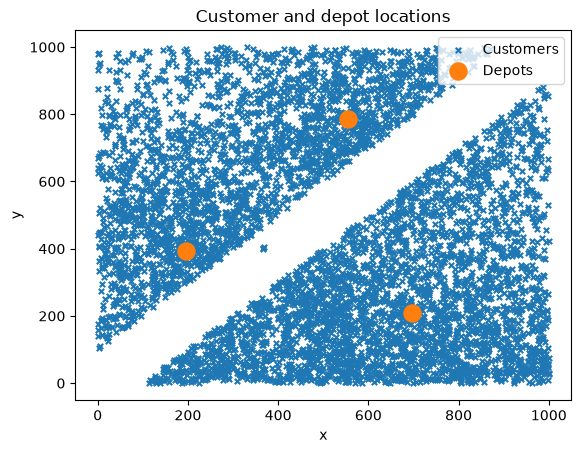

In [10]:
plt.scatter(
    X["x"],
    X["y"],
    marker="x",
    s=15,
    label="Customers"
)

plt.scatter(
    depot_locations[:, 0],
    depot_locations[:, 1],
    marker="o",
    s=150,
    label="Depots"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Customer and depot locations")
plt.legend()
plt.show()

In [11]:
df_with_depot = df.copy()

df_with_depot['nearest_depot'] = kmeans_model.labels_

display(df_with_depot.head(10))

,clientid,x,y,nearest_depot
0,1,622.771572,164.857623,1
1,2,416.357298,630.193634,2
2,3,292.735020,567.333231,0
3,4,737.211288,166.225676,1
4,5,540.475375,682.912298,2
5,6,535.469492,318.439661,1
6,7,640.380050,870.833221,2
7,8,235.772075,359.048203,0
8,9,481.896884,661.491838,2
9,10,730.032789,312.177817,1


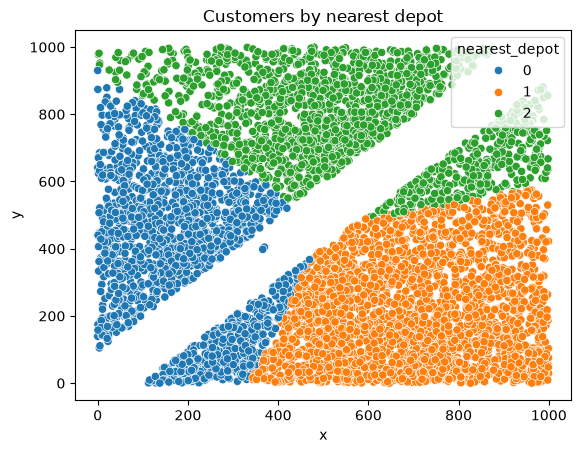

In [12]:
sns.scatterplot(
    data=df_with_depot,
    x="x",
    y="y",
    hue="nearest_depot",
    palette="tab10"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Customers by nearest depot")
plt.show()

## Breakdown

The KMeans centroids represent the proposed depot locations. With three
clusters, each centroid is positioned near the geographical center of one
group of clients. Scatterplot visualizes the distributions of neares depots by color. It seems to be distributed evenly

# 5. Evaluation

For KMeans algorithm evaluation is best to use `elbow` -method to select `K` values for further evaluation

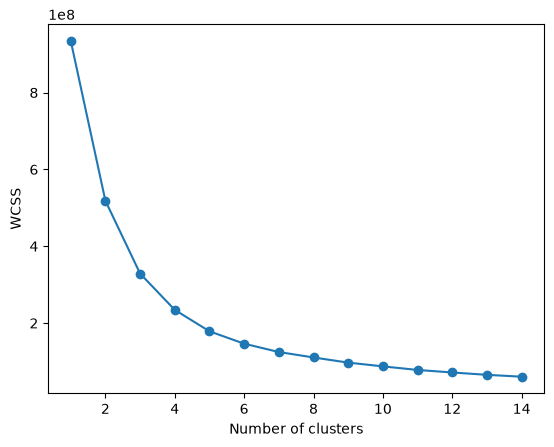

In [13]:
wcss_kmeans = []
for i in range(1,15):
    model = KMeans(init='random', n_clusters=i, random_state=random_state).fit(X)
    wcss_kmeans.append(model.inertia_)
    
plt.plot(range(1,15), wcss_kmeans, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## Elbow method breakdown

WCSS seems to stabilize between `K` value of 3 to 6. Higher depot count does not improve alot after value of `6`, but lets take deeper look including `2`, `7` and `8` values as well.

In [14]:
n_clusters_list = [2, 3, 4, 5, 6, 7, 8]

## Silhouette score

Let's compare above determined `K` values with silhouette score

In [20]:
for n_clusters in n_clusters_list:
    model = KMeans(init='random', n_clusters=n_clusters, random_state=random_state).fit(X)
    labels = model.labels_
    print(f'Silhouette score for k value of {n_clusters}: {silhouette_score(X, labels): .5f}')

Silhouette score for k value of 2:  0.42280
Silhouette score for k value of 3:  0.42284
Silhouette score for k value of 4:  0.40276
Silhouette score for k value of 5:  0.41821
Silhouette score for k value of 6:  0.39931
Silhouette score for k value of 7:  0.38844
Silhouette score for k value of 8:  0.38872


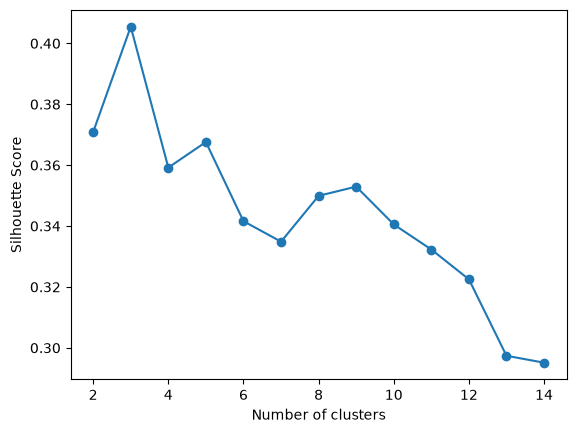

Silhouette score for numbers of clusters 2:  0.371
Silhouette score for numbers of clusters 3:  0.405
Silhouette score for numbers of clusters 4:  0.359
Silhouette score for numbers of clusters 5:  0.368
Silhouette score for numbers of clusters 6:  0.342
Silhouette score for numbers of clusters 7:  0.335
Silhouette score for numbers of clusters 8:  0.350
Silhouette score for numbers of clusters 9:  0.353
Silhouette score for numbers of clusters 10:  0.341
Silhouette score for numbers of clusters 11:  0.332
Silhouette score for numbers of clusters 12:  0.322
Silhouette score for numbers of clusters 13:  0.297
Silhouette score for numbers of clusters 14:  0.295


In [21]:
silhouette_scores = []

for i in range(2,15):
    model = AgglomerativeClustering(n_clusters=i)
    predict = model.fit_predict(X)

    silhouette_score_for_model = silhouette_score(X, predict)
    silhouette_scores.append(silhouette_score_for_model)

plt.plot(range(2,15), silhouette_scores, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

for i, score in enumerate(silhouette_scores):
    print(f"Silhouette score for numbers of clusters {i+2}: {score: .3f}")

## Visualize the depot stations in the cartasian coordinate system with **`2-10`**.

### KMeans


2 depots proposed coordinates:
Depot 1 coordinates:
x: 334.49  y: 658.99
Depot 2 coordinates:
x: 654.08  y: 234.73


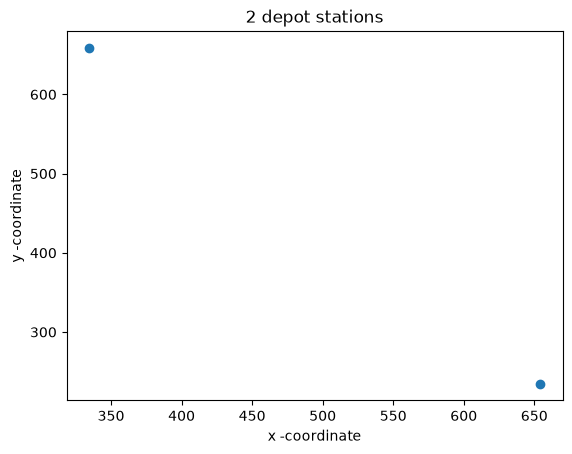


3 depots proposed coordinates:
Depot 1 coordinates:
x: 194.80  y: 392.58
Depot 2 coordinates:
x: 697.70  y: 208.36
Depot 3 coordinates:
x: 555.30  y: 785.46


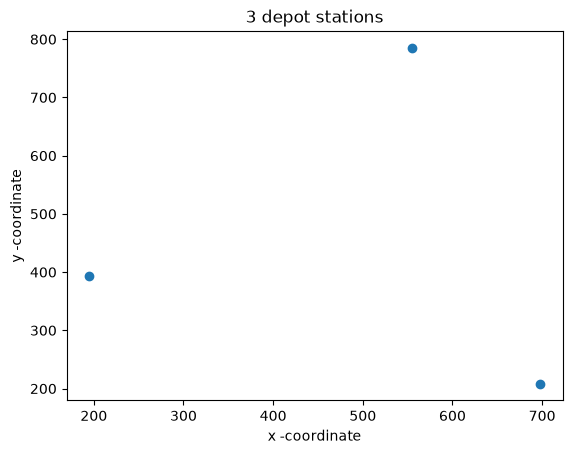


4 depots proposed coordinates:
Depot 1 coordinates:
x: 172.73  y: 532.03
Depot 2 coordinates:
x: 435.57  y: 140.59
Depot 3 coordinates:
x: 593.96  y: 792.69
Depot 4 coordinates:
x: 799.24  y: 248.52


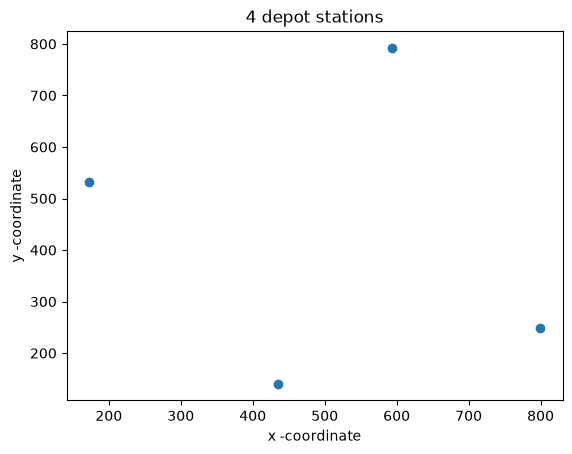


5 depots proposed coordinates:
Depot 1 coordinates:
x: 161.67  y: 496.43
Depot 2 coordinates:
x: 437.55  y: 148.27
Depot 3 coordinates:
x: 487.90  y: 825.49
Depot 4 coordinates:
x: 804.49  y: 152.08
Depot 5 coordinates:
x: 807.40  y: 531.83


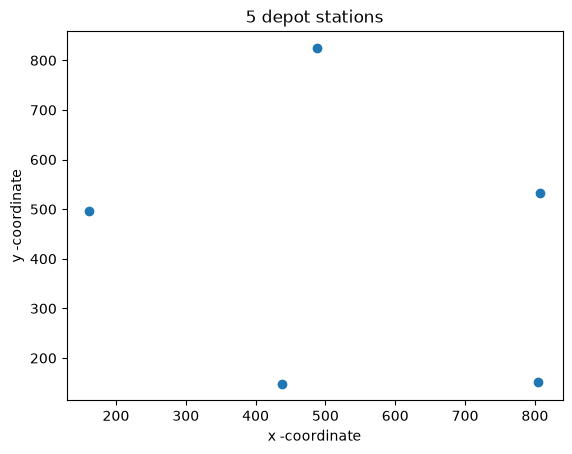


6 depots proposed coordinates:
Depot 1 coordinates:
x: 156.49  y: 423.46
Depot 2 coordinates:
x: 247.15  y: 746.81
Depot 3 coordinates:
x: 572.01  y: 837.68
Depot 4 coordinates:
x: 804.72  y: 151.16
Depot 5 coordinates:
x: 437.18  y: 148.03
Depot 6 coordinates:
x: 806.33  y: 530.32


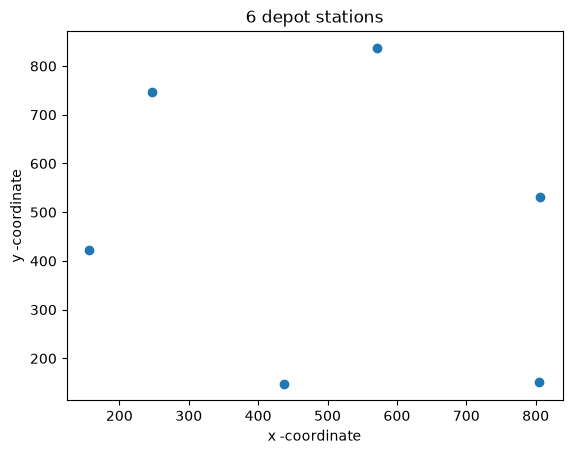


7 depots proposed coordinates:
Depot 1 coordinates:
x: 277.26  y: 95.70
Depot 2 coordinates:
x: 554.65  y: 199.13
Depot 3 coordinates:
x: 250.97  y: 765.88
Depot 4 coordinates:
x: 842.61  y: 144.23
Depot 5 coordinates:
x: 824.11  y: 544.95
Depot 6 coordinates:
x: 168.51  y: 450.33
Depot 7 coordinates:
x: 574.79  y: 836.09


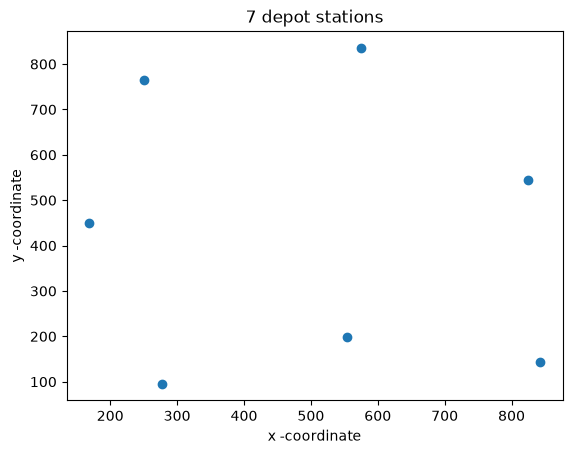


8 depots proposed coordinates:
Depot 1 coordinates:
x: 326.58  y: 87.22
Depot 2 coordinates:
x: 568.62  y: 210.00
Depot 3 coordinates:
x: 377.92  y: 633.71
Depot 4 coordinates:
x: 586.37  y: 866.09
Depot 5 coordinates:
x: 846.77  y: 141.43
Depot 6 coordinates:
x: 176.88  y: 801.76
Depot 7 coordinates:
x: 826.60  y: 546.79
Depot 8 coordinates:
x: 138.41  y: 411.98


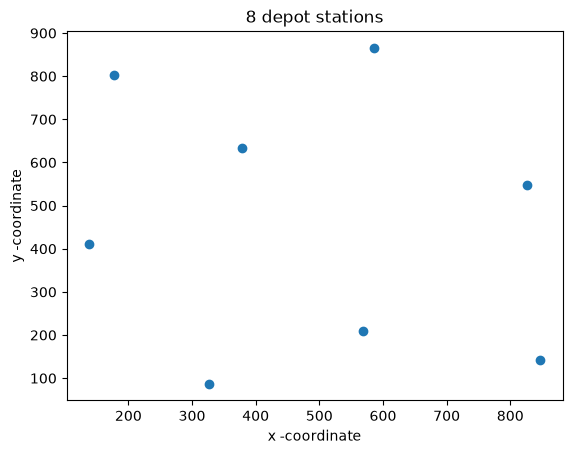


9 depots proposed coordinates:
Depot 1 coordinates:
x: 173.61  y: 806.44
Depot 2 coordinates:
x: 598.67  y: 879.13
Depot 3 coordinates:
x: 262.18  y: 97.99
Depot 4 coordinates:
x: 156.22  y: 441.54
Depot 5 coordinates:
x: 880.67  y: 630.49
Depot 6 coordinates:
x: 722.52  y: 398.26
Depot 7 coordinates:
x: 536.44  y: 162.43
Depot 8 coordinates:
x: 847.87  y: 130.30
Depot 9 coordinates:
x: 410.30  y: 676.97


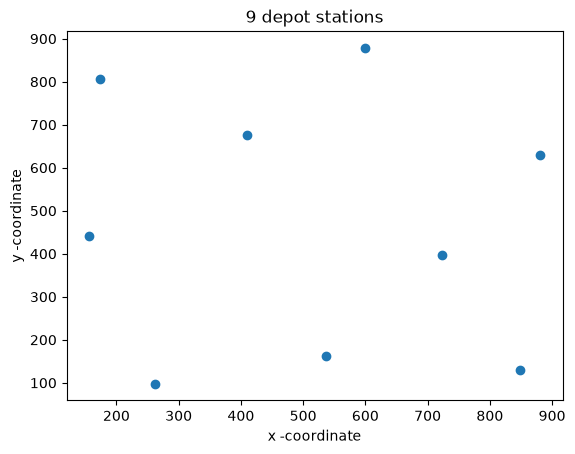


10 depots proposed coordinates:
Depot 1 coordinates:
x: 183.38  y: 830.46
Depot 2 coordinates:
x: 103.22  y: 327.03
Depot 3 coordinates:
x: 625.76  y: 894.07
Depot 4 coordinates:
x: 447.95  y: 728.58
Depot 5 coordinates:
x: 882.29  y: 647.60
Depot 6 coordinates:
x: 310.94  y: 86.64
Depot 7 coordinates:
x: 200.88  y: 523.54
Depot 8 coordinates:
x: 748.59  y: 408.92
Depot 9 coordinates:
x: 548.48  y: 178.06
Depot 10 coordinates:
x: 846.78  y: 125.63


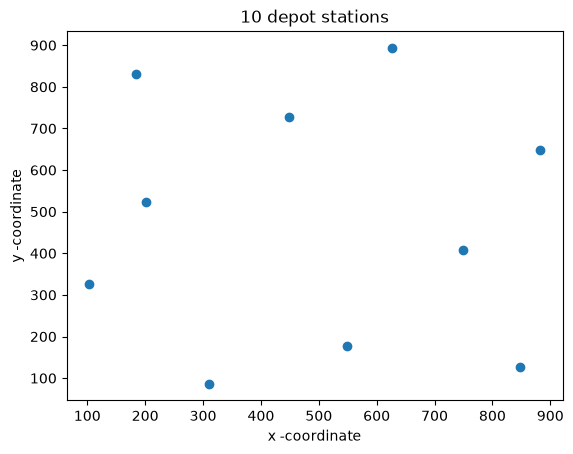

2 depots took  0.028 seconds to be completed
3 depots took  0.029 seconds to be completed
4 depots took  0.035 seconds to be completed
5 depots took  0.030 seconds to be completed
6 depots took  0.069 seconds to be completed
7 depots took  0.038 seconds to be completed
8 depots took  0.044 seconds to be completed
9 depots took  0.052 seconds to be completed
10 depots took  0.041 seconds to be completed


In [29]:
depot_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]
time_list = []

for depots in depot_list:
    start_time = time.perf_counter()
    model = KMeans(init='random', n_clusters=depots, random_state=random_state)
    model.fit(X)
    
    centers = model.cluster_centers_
    end_time = time.perf_counter()
    duration = end_time - start_time
    time_string = f'{depots} depots took {duration: .3f} seconds to be completed'
    time_list.append(time_string)
    print(f"\n{depots} depots proposed coordinates:")
    for i, coordinate in enumerate(centers, start=1):
        print(f"Depot {i} coordinates:")
        print(f"x: {coordinate[0]:.2f}  y: {coordinate[1]:.2f}")
    plt.plot(centers[:, 0], centers[:, 1], 'o')
    plt.title(f"{depots} depot stations")
    plt.xlabel("x -coordinate")
    plt.ylabel("y -coordinate")
    plt.show()

for string in time_list:
    print(string)

### Agglomerative clusterring

`Agglomerative clustering` does not directly provide cluster centroids. The proposed depot location for each cluster is calculated as the mean `x` and `y` coordinate of the customers belonging to that cluster.

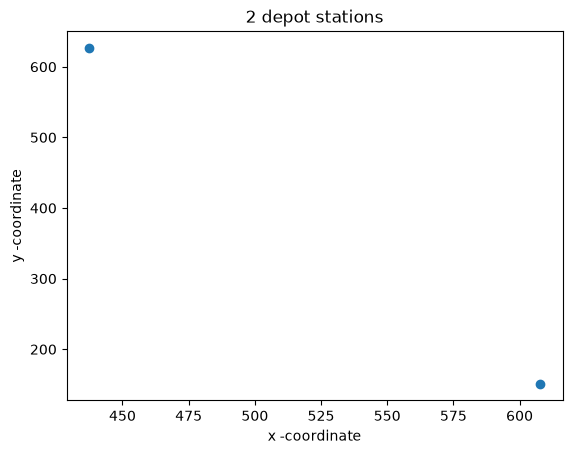

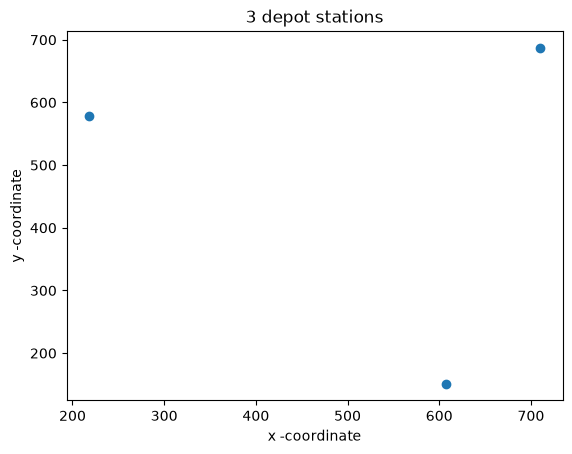

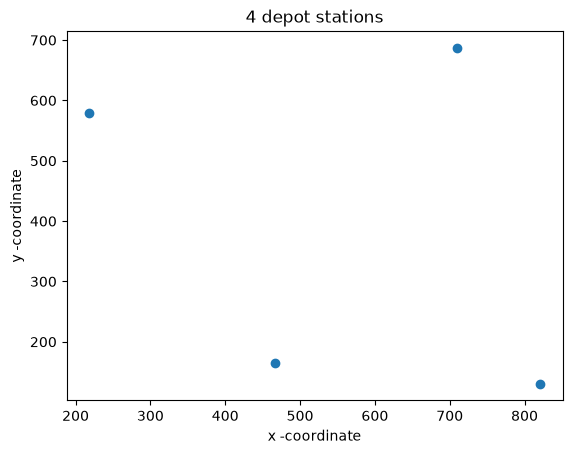

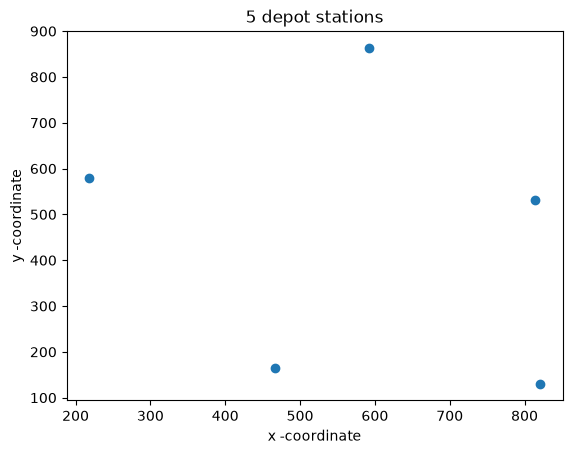

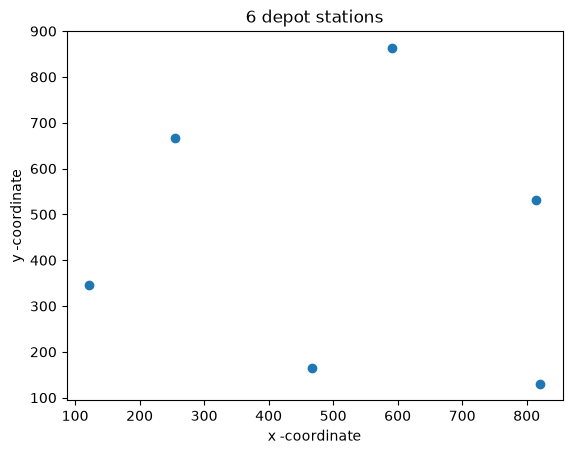

2 depots took  0.218 seconds to be completed
3 depots took  0.226 seconds to be completed
4 depots took  0.221 seconds to be completed
5 depots took  0.229 seconds to be completed
6 depots took  0.217 seconds to be completed


In [18]:
time_list_agglo = []
for depots in depot_list:
    start_time = time.perf_counter()
    model = AgglomerativeClustering(n_clusters=depots)

    predict = model.fit_predict(X)
    
    temp = X.copy()
    temp["cluster"] = predict

    # calculating the depot stations place in the coordinate
    centers = temp.groupby("cluster")[["x", "y"]].mean()
    end_time = time.perf_counter()
    duration = end_time - start_time
    time_string = f'{depots} depots took {duration: .3f} seconds to be completed'
    time_list_agglo.append(time_string)
    
    plt.plot(centers["x"], centers["y"], 'o')
    plt.title(f"{depots} depot stations")
    plt.xlabel("x -coordinate")
    plt.ylabel("y -coordinate")
    plt.show()

for string in time_list_agglo:
    print(string)

## Depot stations conclusion

Based on the clustering metrics, **`three`** depots provide a reasonable compromise for this dataset. However, the truly optimal number of depots would also depend
on operational factors such as depot construction costs, drone range, delivery
times and depot capacity.

The `KMeans` computation time generally increases as the number of clusters increases, although individual measurements fluctuate because the execution times are very short.

Time for calculating depot in agglomerative locations seems not to cumulative raise like in KMeans method. Allthough `agglomerative` algorithm is less time efficient than `KMeans`.

## Evaluation conclusion

`Agglomerative clustering` produces broadly similar geographical groupings to `KMeans`, but the exact cluster boundaries and proposed depot locations differ. For **`three`** clusters, `KMeans` produces a slightly higher silhouette score.

On this dataset, `agglomerative clustering` was also noticeably slower than KMeans.

### KMeans
As seen on `Elbow` method the `K` value should be in between 3 to 6. With `Silhouette score` the `K` value should be either `2`, `3` or `5` as all of them is around 0.42. `K` value of **`3`** seems to be the best give slightly better silhouette score. The score approximately `0.423` is not great, but it is the best score we get as we see it to get lower with bigger `K` values. Either way `silhouette score` `0.423` means that many of the clusters overlap some what each other. Its not bad, but higher value would provide better confidence to the algorithm.

### Agglomerative clustering
Plotting indicates optimal `K`value to be **`3`**. It comes with silhouette_score **`0.405`** when the nearest are `K`value of **`2`**: **`0.371`** and `K`value of 4: **`0.359`**

# 6. Deployment

`KMeans` algorithm might not suit the best for this data due low `silhouette score` `0.423`. It is not the worst, because it is in 0.4 to 0.45 -range, which conclude reasonable clustering structure.

`Agglomerative clustering` gives lower `silhouete score` of **`0.405`** against `KMeans`**`0.423`** with same `K` values of **`3`**.

For this dataset, `KMeans` is considerably faster than `agglomerative clustering`. The `KMeans` runs took only a few hundredths of a second, while `agglomerative clustering` required approximately 0.22 seconds.

## Recommendation

For this dataset, `KMeans` is the more practical choice for depot placement.

With **`three`** depots, `KMeans` achieved a slightly higher silhouette score than agglomerative clustering and was considerably faster in the measured runs.

**`Three`** depots provide a reasonable starting configuration, but the optimal number of depots ultimately depends on operational constraints and costs that are not included in this dataset.